<a href="https://colab.research.google.com/github/A-n9ie/proyecto_analisis_datos_IC2026/blob/master/github_colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import auth
auth.authenticate_user()
print('Authenticated')

Authenticated


Renombramiento de columnas principales (al unir csv\)

In [2]:
def renombrar_columnas_principales(df):
    return df.rename(columns={
        'year': 'año',
        'Sex': 'sexo',
        'type': 'tipo',
        'noc': 'pais_codigo',
        'medal': 'medalla',
        'discipline': 'disciplina'
    })

# Función para unir los .CSV de la Biografía de los atletas junto con el de los Resultados de los Juegos Olímpicos

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.patheffects as path_effects

In [4]:
def preparar_df_unido(results, bios, start=1896, end=2022):
    df = results.merge(bios[['athlete_id', 'Sex']], on='athlete_id', how='left')

    # Normalizar Sex
    df['Sex'] = df['Sex'].astype(str).str.strip().str.capitalize()
    df.loc[~df['Sex'].isin(['Male', 'Female']), 'Sex'] = pd.NA

    # Limpiar year
    df['year'] = pd.to_numeric(df['year'], errors='coerce')
    df = df[df['year'].between(start, end)]

    # (opcional) quitar filas sin Sex (no se pueden clasificar)
    df = df.dropna(subset=['Sex'])

    # Renombrar columnas al español
    df = renombrar_columnas_principales(df)

    # Traducir valores de sexo
    df['sexo'] = df['sexo'].map({'Male': 'Hombre', 'Female': 'Mujer'})

    return df

In [7]:
bios = pd.read_csv("/content/bios.csv")
results = pd.read_csv("/content/results.csv")
df = preparar_df_unido(results, bios)

Renombramiento de columnas generadas

In [51]:
def renombrar_columnas(df_resultado):
    renombres = {
        'female_event_entries': 'participaciones_femeninas',
        'first_female_year': 'primer_anio_femenino',
        'years_until_inclusion': 'anios_hasta_inclusion',
        'total_female_participations': 'total_participaciones_femeninas',
        'total_female_medals': 'total_medallas_femeninas',
        'medal_conversion_rate': 'tasa_conversion_medallas',
        'num_disciplinas': 'numero_disciplinas',
        'Gold': 'Oro',
        'Silver': 'Plata',
        'Bronze': 'Bronce'
    }
    return df_resultado.rename(columns=renombres)

# Evolución de porcentaje de participación femenina en los Juegos Olímpicos desde 1896 hasta el 2022

In [52]:
def proporcion_femenina_por_anio(df):
    agrupado = df.groupby(['año', 'sexo']).size().unstack(fill_value=0)

    agrupado['total'] = agrupado.sum(axis=1)
    agrupado['porcentaje_femenino'] = (agrupado['Mujer'] / agrupado['total']) * 100

    return agrupado.reset_index()

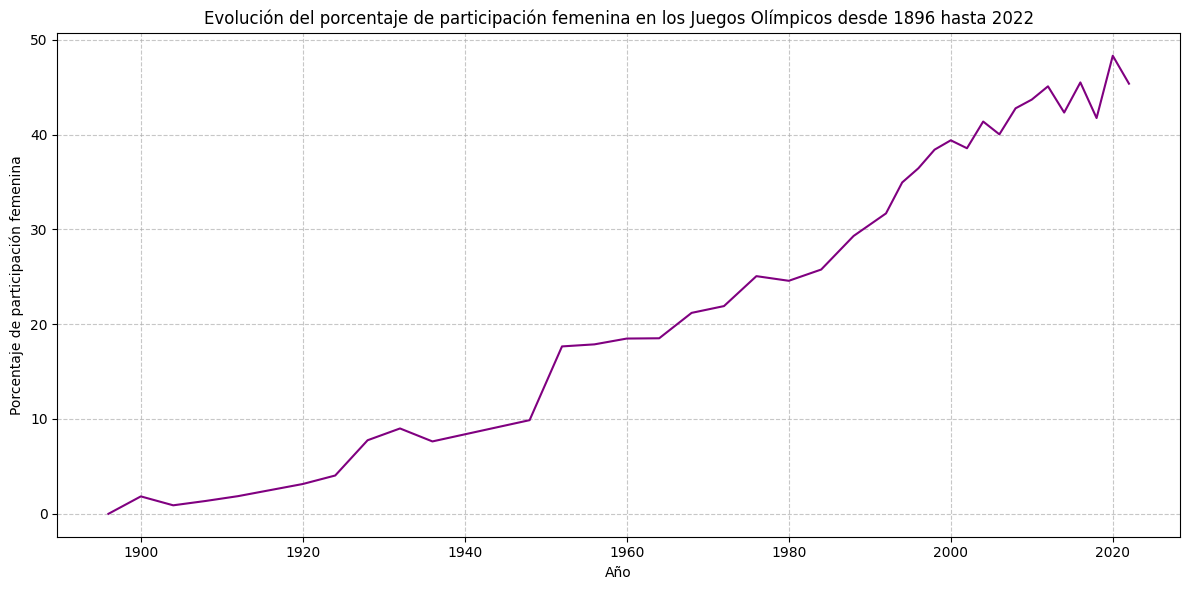

In [53]:
# Proporción femenina por año
data = proporcion_femenina_por_anio(df)

plt.figure(figsize=(12, 6)) # Establecer un tamaño de figura para mejor visibilidad
plt.plot(data['año'], data['porcentaje_femenino'], color='purple') # Cambiar el color de la línea
plt.title("Evolución del porcentaje de participación femenina en los Juegos Olímpicos desde 1896 hasta 2022")
plt.xlabel("Año")
plt.ylabel("Porcentaje de participación femenina")
plt.grid(True, linestyle='--', alpha=0.7) # Añadir una cuadrícula para información básica
plt.tight_layout() # Ajustar el diseño para evitar que las etiquetas se corten
plt.show()

# Evoluación del porcentaje de participación femenina desde 1896 hasta 2022 en Verano vs Invierno

In [71]:
def proporcion_femenina_por_anio_y_tipo(df):
    # Conteos por año, tipo (Summer/Winter) y sexo
    agrupado = (df.groupby(['año', 'tipo', 'sexo'])
                  .size()
                  .unstack(fill_value=0)
                  .reset_index())

    # Total por (año,tipo)
    agrupado['total'] = agrupado.get('Hombre', 0) + agrupado.get('Mujer', 0)
    agrupado['porcentaje_femenino'] = (agrupado.get('Mujer', 0) / agrupado['total']) * 100



    return agrupado[['año', 'tipo', 'porcentaje_femenino']]

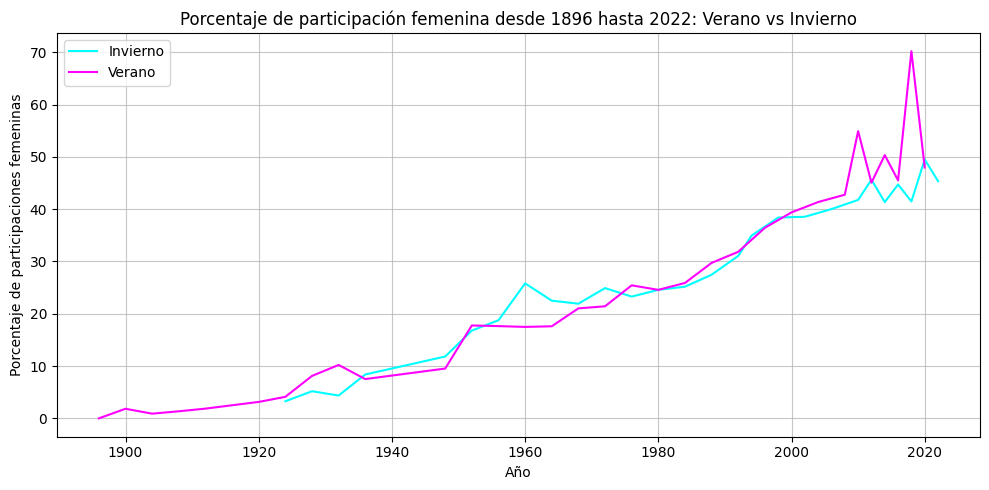

In [75]:
# Comparativa Summer vs Winter
data_type = proporcion_femenina_por_anio_y_tipo(df)

plt.figure(figsize=(10,5))

# Definir un diccionario de colores para cada tipo
colors = {'Verano': 'fuchsia', 'Invierno': 'aqua'}

for t in sorted(data_type['tipo'].dropna().unique()):
    sub = data_type[data_type['tipo'] == t].sort_values('año')
    plt.plot(sub['año'], sub['porcentaje_femenino'], label=t, color=colors.get(t)) # Usar los colores definidos

plt.title("Porcentaje de participación femenina desde 1896 hasta 2022: Verano vs Invierno")
plt.xlabel("Año")
plt.ylabel("Porcentaje de participaciones femeninas")
plt.legend()
plt.grid(True, alpha=0.7) # Aumentar la visibilidad de la cuadrícula
plt.tight_layout() # Ajustar el diseño para evitar que las etiquetas se corten
plt.show()

# Top 5 países con más participaciones femeninas

In [56]:
def top_5_paises_participaciones_femeninas(df, start=1896, end=2022, tipo_juegos=None):
    d = df.copy()
    d['año'] = pd.to_numeric(d['año'], errors='coerce')
    d = d[d['año'].between(start, end)]
    d = d[d['sexo'] == 'Mujer']

    if tipo_juegos is not None:
        d = d[d['tipo'] == tipo_juegos]

    top = (d.groupby('pais_codigo')
            .size()
            .sort_values(ascending=False)
            .head(5)
            .reset_index(name='participaciones_femeninas'))

    return renombrar_columnas(top)

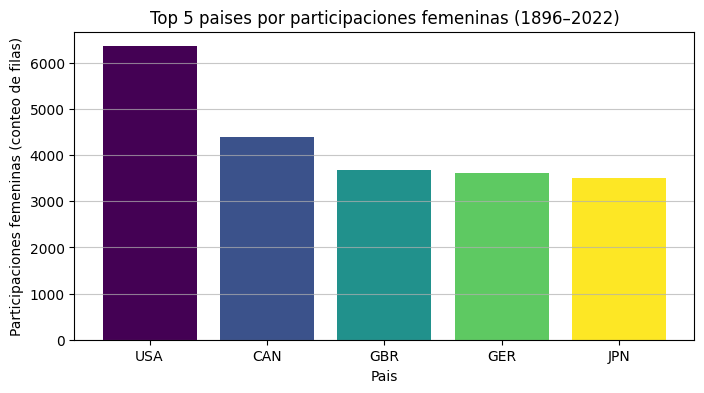

In [57]:
# Top 5 países
top5 = top_5_paises_participaciones_femeninas(df)
plt.figure(figsize=(8,4))

# Usar un mapa de colores para las barras, asegurando una distribución más uniforme
colors = plt.cm.viridis(np.linspace(0, 1, len(top5)))
plt.bar(top5['pais_codigo'], top5['participaciones_femeninas'], color=colors)
plt.title("Top 5 paises por participaciones femeninas (1896–2022)")
plt.xlabel("Pais")
plt.ylabel("Participaciones femeninas (conteo de filas)")
plt.grid(axis='y', alpha=0.7) # Aumentar la visibilidad de la cuadrícula
plt.show()

# Top 5 disciplinas con más participación femenina y su evolución

In [58]:
def participaciones_femeninas_top_disciplinas_evolucion(df, n=5, start=1896, end=2022, tipo_juegos=None):
    d = df.copy()
    d['año'] = pd.to_numeric(d['año'], errors='coerce')
    d = d[d['año'].between(start, end)]
    d = d[d['sexo'] == 'Mujer']

    if tipo_juegos is not None:
        d = d[d['tipo'] == tipo_juegos]

    # Top disciplinas globales
    top_disc = (d.groupby('disciplina')
                 .size()
                 .sort_values(ascending=False)
                 .head(n)
                 .index.tolist())

    # Serie temporal solo con esas disciplinas
    serie = (d[d['disciplina'].isin(top_disc)]
              .groupby(['año', 'disciplina'])
              .size()
              .reset_index(name='participaciones_femeninas'))

    return top_disc, renombrar_columnas(serie)

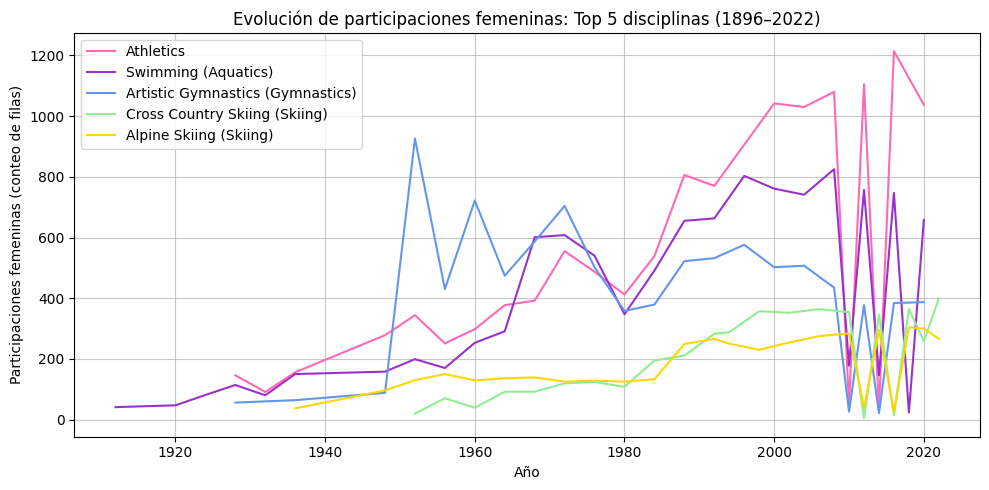

In [59]:
# Top 5 disciplinas evolución
top_disc, serie = participaciones_femeninas_top_disciplinas_evolucion(df, n=5)
plt.figure(figsize=(10,5))

# Usar un mapa de colores para las líneas
# Custom "girly" colors: HotPink, DarkOrchid, CornflowerBlue, LightGreen, Gold
colores_linea  = ['#FF69B4', '#9932CC', '#6495ED', '#90EE90', '#FFD700']

for i, disc in enumerate(top_disc):
    sub = serie[serie['disciplina'] == disc].sort_values('año')
    plt.plot(sub['año'], sub['participaciones_femeninas'], label=disc, color=colores_linea[i % len(colores_linea)])
plt.title("Evolución de participaciones femeninas: Top 5 disciplinas (1896–2022)")
plt.xlabel("Año")
plt.ylabel("Participaciones femeninas (conteo de filas)")
plt.legend()
plt.grid(True, alpha=0.7)
plt.tight_layout()
plt.show()


Comparación directa de participaciones masculinas vs femeninas por año en las olimpiadas

In [60]:
def comparativa_genero_por_anio(df):
    agrupado = df.groupby(['año', 'sexo']).size().unstack(fill_value=0)

    if 'Mujer' not in agrupado.columns:
        agrupado['Mujer'] = 0
    if 'Hombre' not in agrupado.columns:
        agrupado['Hombre'] = 0

    return agrupado.reset_index()[['año', 'Mujer', 'Hombre']]

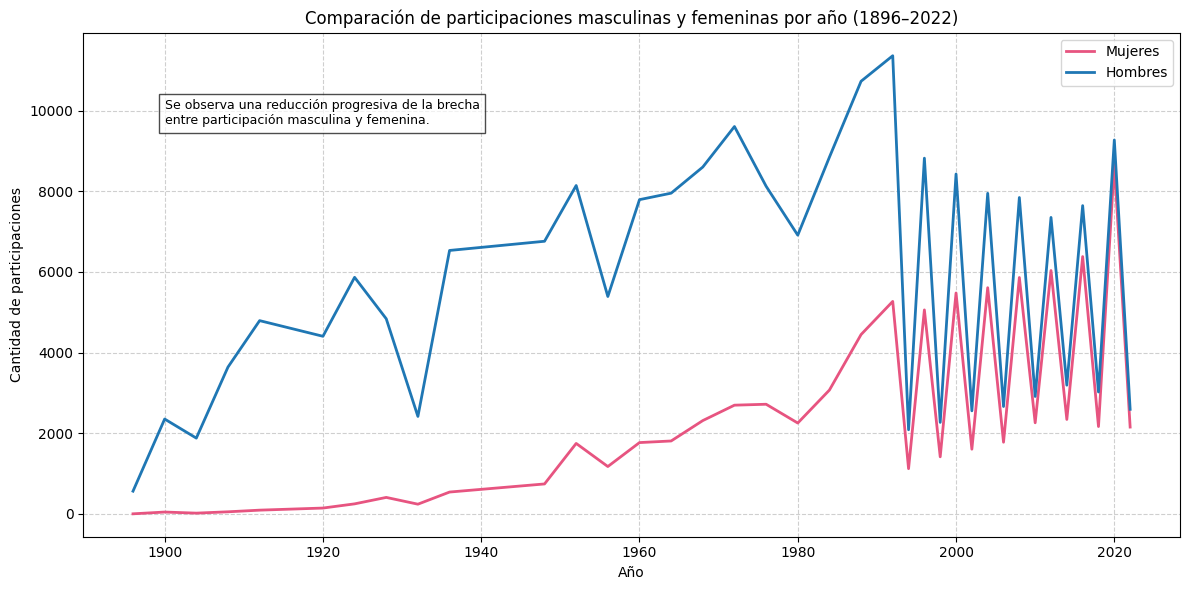

In [61]:
# Comparativa hombres vs mujeres
datos_genero = comparativa_genero_por_anio(df)

plt.figure(figsize=(12,6))
plt.plot(datos_genero['año'], datos_genero['Mujer'], label='Mujeres', color='#E75480', linewidth=2)
plt.plot(datos_genero['año'], datos_genero['Hombre'], label='Hombres', color='#1F77B4', linewidth=2)

plt.title("Comparación de participaciones masculinas y femeninas por año (1896–2022)")
plt.xlabel("Año")
plt.ylabel("Cantidad de participaciones")
plt.legend()

plt.grid(True, linestyle='--', alpha=0.6)
plt.text(1900, datos_genero['Hombre'].max()*0.85,
         "Se observa una reducción progresiva de la brecha\nentre participación masculina y femenina.",
         fontsize=9, bbox=dict(facecolor='white', alpha=0.7))

plt.tight_layout()
plt.show()

Distribución de medallas por sexo

In [62]:
def conteo_medallas_por_sexo(df):
    d = df.dropna(subset=['medalla']).copy()

    agrupado = d.groupby(['sexo', 'medalla']).size().unstack(fill_value=0)

    for medalla in ['Gold', 'Silver', 'Bronze']:
        if medalla not in agrupado.columns:
            agrupado[medalla] = 0

    # Traducir nombres de medallas
    return renombrar_columnas(agrupado[['Gold', 'Silver', 'Bronze']].reset_index())

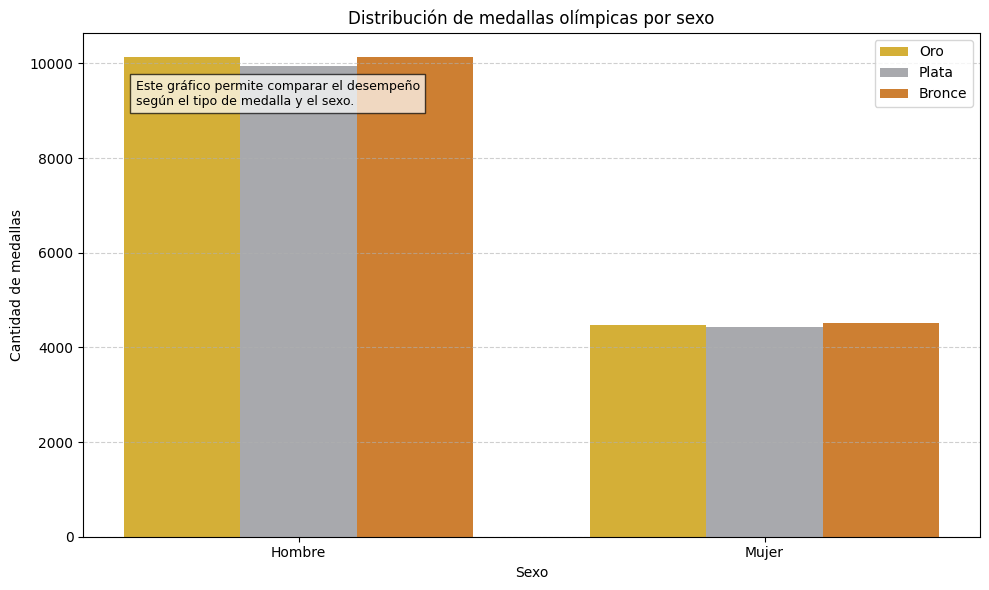

In [70]:
# Distribución de medallas por sexo
medallas_data = conteo_medallas_por_sexo(df)

x = range(len(medallas_data))
ancho = 0.25

plt.figure(figsize=(10,6))
plt.bar([i - ancho for i in x], medallas_data['Oro'], width=ancho, label='Oro', color='#D4AF37')
plt.bar(x, medallas_data['Plata'], width=ancho, label='Plata', color='#A8A9AD')
plt.bar([i + ancho for i in x], medallas_data['Bronce'], width=ancho, label='Bronce', color='#CD7F32')

plt.xticks(x, medallas_data['sexo'])
plt.title("Distribución de medallas olímpicas por sexo")
plt.xlabel("Sexo")
plt.ylabel("Cantidad de medallas")
plt.legend()

plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.text(-0.35, max(medallas_data[['Oro','Plata','Bronce']].max())*0.9,
         "Este gráfico permite comparar el desempeño\nsegún el tipo de medalla y el sexo.",
         fontsize=9, bbox=dict(facecolor='white', alpha=0.7))

plt.tight_layout()
plt.show()

# PRIMER PARTICIPACIÓN FEMENINA POR DISCIPLINA

Este análisis identifica el primer año en el que cada disciplina deportiva registró participación femenina en los Juegos Olímpicos (1896–2022). Para cada disciplina se calcula el año de inclusión, los años transcurridos desde 1896, el total de participaciones femeninas, las medallas obtenidas por mujeres y la tasa de conversión (medallas por cada 100 participaciones). Los resultados se ordenan desde las disciplinas más recientes hasta las más antiguas.

La visualización mediante barras horizontales con colores degradados (rojo = incorporación reciente, verde = incorporación temprana) permite observar el proceso histórico de apertura del deporte olímpico a las mujeres. Además, se puede evaluar el rendimiento femenino en cada disciplina a través de la tasa de conversión de medallas.

In [64]:
def primer_participacion_femenina_por_disciplina(df):
    # Trabajar sobre una copia para no modificar el original
    d = df.copy()

    # Asegurar que 'año' sea numérico y eliminar filas sin año o disciplina (limpiar)
    d['año'] = pd.to_numeric(d['año'], errors='coerce')
    d = d.dropna(subset=['año', 'disciplina'])

    # Filtrar solo registros de mujeres -> participación femenina
    df_mujeres = d[d['sexo'] == 'Mujer'].copy()

    # Primer año de participación femenina por disciplina
    primer_anio = df_mujeres.groupby('disciplina')['año'].min().reset_index()
    primer_anio.columns = ['disciplina', 'primer_anio_femenino']
    primer_anio['primer_anio_femenino'] = primer_anio['primer_anio_femenino'].astype(int)

    # Años transcurridos desde 1896 (inicio de Juegos modernos)
    primer_anio['anios_hasta_inclusion'] = primer_anio['primer_anio_femenino'] - 1896

    # Total de participaciones femeninas (número de filas) por disciplina
    total_participaciones = df_mujeres.groupby('disciplina').size().reset_index(name='total_participaciones_femeninas')

    # Total de medallas ganadas por mujeres (solo registros con medalla no nula)
    total_medallas = df_mujeres.dropna(subset=['medalla']).groupby('disciplina').size().reset_index(name='total_medallas_femeninas')

    # Unir todos los DataFrames
    resultado = primer_anio.merge(total_participaciones, on='disciplina', how='left')
    resultado = resultado.merge(total_medallas, on='disciplina', how='left')
    resultado['total_medallas_femeninas'] = resultado['total_medallas_femeninas'].fillna(0).astype(int)

    # Tasa de conversión: medallas por cada 100 participaciones
    resultado['tasa_conversion_medallas'] = (
        (resultado['total_medallas_femeninas'] / resultado['total_participaciones_femeninas']) * 100
    ).round(2)

    # Ordenar por año descendente (las disciplinas más recientes primero)
    resultado = resultado.sort_values('primer_anio_femenino', ascending=False).reset_index(drop=True)

    # ordenar columnas finales
    columnas_finales = [
        'disciplina',
        'primer_anio_femenino',
        'anios_hasta_inclusion',
        'total_participaciones_femeninas',
        'total_medallas_femeninas',
        'tasa_conversion_medallas'
    ]

    return renombrar_columnas(resultado[columnas_finales])

In [65]:
def visualizar_primer_participacion_femenina(df, top_n=15, orden='reciente'):
    # Cargar los datos de primer año de participación femenina por disciplina
    datos = primer_participacion_femenina_por_disciplina(df)

    # Obtener los años extremos para la escala de colores
    min_anio = datos['primer_anio_femenino'].min()
    max_anio = datos['primer_anio_femenino'].max()

    # Seleccionar según el orden solicitado y definir subtítulo
    if orden == 'reciente':
        datos = datos.head(top_n)
        subtitulo = "Últimas Disciplinas en Incorporar Mujeres"
    else:
        datos = datos.tail(top_n)
        subtitulo = "Primeras Disciplinas en Incorporar Mujeres"

    # Ordenar para que el año más antiguo aparezca arriba en el gráfico
    datos = datos.sort_values('primer_anio_femenino', ascending=True)

    # Crear la figura y los ejes
    fig, ax = plt.subplots(figsize=(12, 8))

    # Generar colores degradados según el año (más antiguo verde, más reciente rojo)
    colores = plt.cm.RdYlGn_r(
        (datos['primer_anio_femenino'] - min_anio) / (max_anio - min_anio)
    )

    # Dibujar barras horizontales
    barras = ax.barh(datos['disciplina'], datos['primer_anio_femenino'],
                     color=colores, alpha=0.85, edgecolor='black', linewidth=1.2)

    # Añadir etiquetas de año y número de participaciones a cada barra
    for barra, anio, particip in zip(barras,
                                     datos['primer_anio_femenino'],
                                     datos['total_participaciones_femeninas']):

        # Para años anteriores a 1960, colocar la etiqueta fuera de la barra (a la derecha)
        if anio < 1960:
            x_pos = anio + 2
            ha = 'left'
        else:
            # Para años más recientes, colocar la etiqueta dentro de la barra (cerca del final)
            x_pos = anio - 2
            ha = 'right'

        txt = ax.text(x_pos, barra.get_y() + barra.get_height()/2,
                      f'{int(anio)} ({int(particip)} part.)',
                      ha=ha, va='center', fontweight='bold', fontsize=9, color='white')

        # Añadir borde negro al texto para mejorar la legibilidad -> por cambio de color
        txt.set_path_effects([path_effects.withStroke(linewidth=2, foreground='black')])

    # Configurar título, etiquetas de ejes y límites
    ax.set_title(f'Primer Año de Participación Femenina por Disciplina\n{subtitulo} (1896-2022)',
                fontsize=13, fontweight='bold', pad=20)
    ax.set_xlabel('Año de Inclusión Femenina', fontsize=11, fontweight='bold')
    ax.set_ylabel('Disciplina Deportiva', fontsize=11, fontweight='bold')

    # limites antes y despues para crear espacio entre borde y barras
    ax.set_xlim(1895, 2025)

    # Activar cuadrícula en el eje X
    ax.grid(axis='x', alpha=0.3, linestyle='--')
    ax.set_axisbelow(True)

    # Mostrar el año más antiguo y más reciente fuera del área de las barras
    ax.text(0.5, 1.01,
            f'Año más antiguo: {int(min_anio)} | Año más reciente: {int(max_anio)}',
            transform=ax.transAxes, ha='center', fontsize=10, fontweight='bold',
            bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.8))

    textstr = ('Nota: El color gradual representa la antigüedad de inclusión.\n'
               'Rojo = inclusión más reciente | Verde = inclusión más antigua')

    fig.text(0.5, 0.01, textstr, ha='center', fontsize=9,
            bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.7))


    plt.tight_layout(rect=[0, 0.05, 1, 1])
    plt.show()

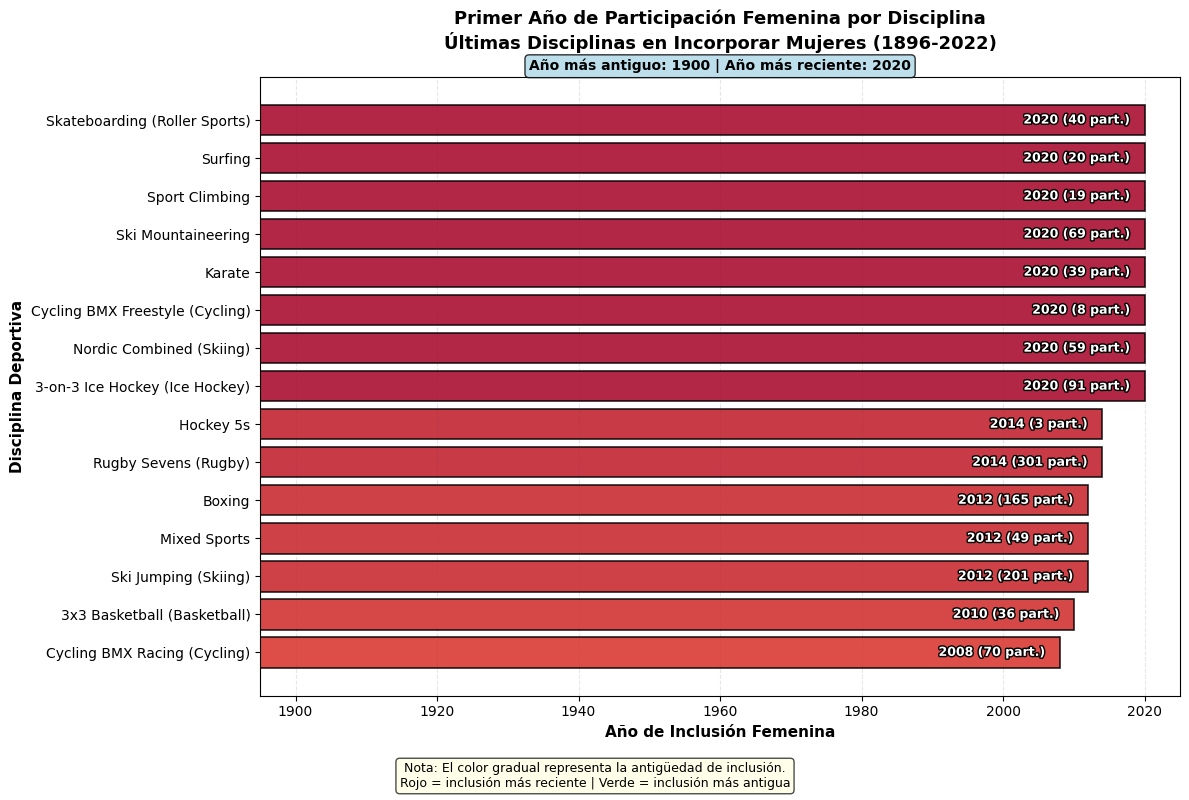

In [66]:
visualizar_primer_participacion_femenina(df)

##**Área Apilada: Evolución de participaciones femeninas en los Top 5 países (1896–2022)**

Este gráfico muestra cómo ha evolucionado la cantidad de participaciones femeninas a lo largo del tiempo en los 5 países con mayor presencia histórica en los Juegos Olímpicos.

Cada color representa un país. La altura de cada franja indica cuántas participaciones femeninas tuvo ese país en cada edición olímpica, y la altura total de la pila refleja el crecimiento general de la participación femenina entre estos países a lo largo de los años.

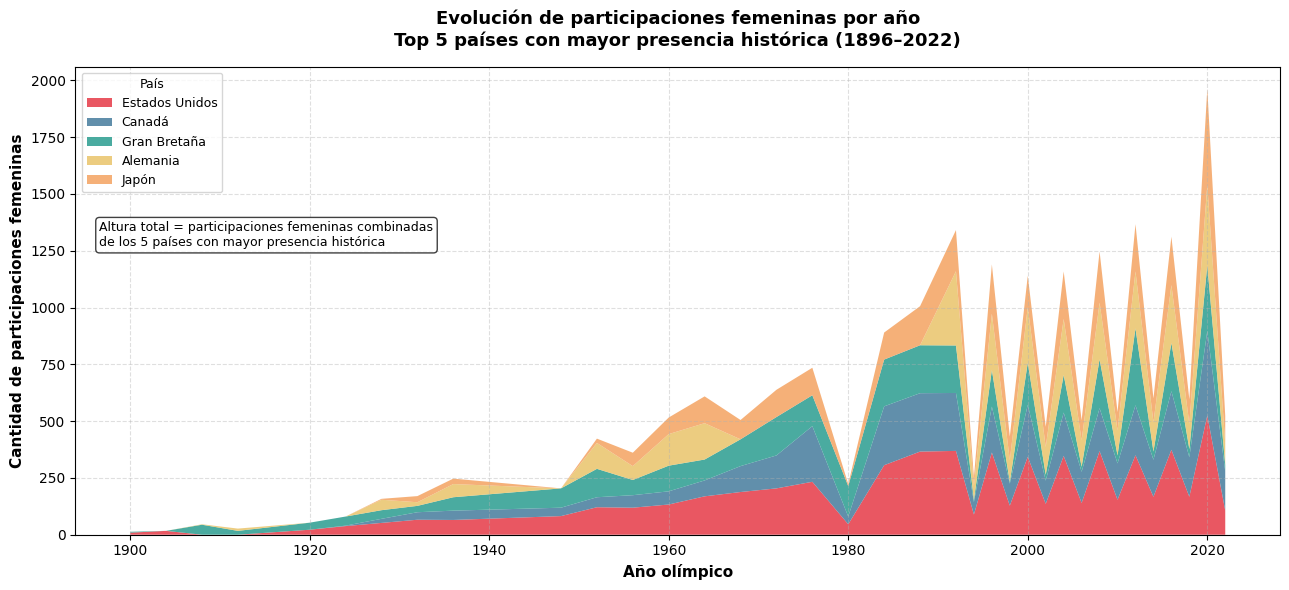

In [67]:
def participacion_femenina_top5_paises(df):
    d = df[df['sexo'] == 'Mujer'].copy()
    d['año'] = pd.to_numeric(d['año'], errors='coerce')
    d = d.dropna(subset=['año', 'pais_codigo'])

    # Top 5 países por total histórico de participaciones femeninas
    top5_nocs = (d.groupby('pais_codigo').size()
                  .sort_values(ascending=False)
                  .head(5)
                  .index.tolist())

    # Nombres completos de los países
    nombres_paises = {
        'USA': 'Estados Unidos',
        'CAN': 'Canadá',
        'GBR': 'Gran Bretaña',
        'GER': 'Alemania',
        'JPN': 'Japón'
    }

    d_top5 = d[d['pais_codigo'].isin(top5_nocs)]
    pivot = (d_top5.groupby(['año', 'pais_codigo'])
                   .size()
                   .unstack(fill_value=0)
                   .reset_index()
                   .sort_values('año'))

    colores_personalizados = ['#E63946', '#457B9D', '#2A9D8F', '#E9C46A', '#F4A261']
    etiquetas = [nombres_paises.get(cod, cod) for cod in top5_nocs]

    fig, ax = plt.subplots(figsize=(13, 6))

    ax.stackplot(
        pivot['año'],
        [pivot[cod] for cod in top5_nocs],
        labels=etiquetas,
        colors=colores_personalizados,
        alpha=0.85
    )

    # Información básica — movida a la derecha para no tapar la leyenda
    ax.text(
        0.02, 0.67,
        'Altura total = participaciones femeninas combinadas\n'
        'de los 5 países con mayor presencia histórica',
        transform=ax.transAxes, fontsize=9, va='top',
        bbox=dict(facecolor='white', alpha=0.75, boxstyle='round')
    )

    ax.set_title(
        'Evolución de participaciones femeninas por año\n'
        'Top 5 países con mayor presencia histórica (1896–2022)',
        fontsize=13, fontweight='bold', pad=15
    )

    ax.set_xlabel('Año olímpico', fontsize=11, fontweight='bold')
    ax.set_ylabel('Cantidad de participaciones femeninas', fontsize=11, fontweight='bold')

    ax.legend(loc='upper left', title='País', fontsize=9, title_fontsize=9)
    ax.grid(True, linestyle='--', alpha=0.4)
    plt.tight_layout()
    plt.show()

participacion_femenina_top5_paises(df)

## **Barras Horizontales: Top 10 países con más medallas de oro femeninas (1896–2022)**

Este gráfico muestra los 10 países que han acumulado más medallas de oro en participaciones femeninas a lo largo de la historia de los Juegos Olímpicos.

A diferencia de los gráficos de participación, este se enfoca en el rendimiento: no solo cuántas mujeres compitieron, sino cuántas lograron el primer lugar en su disciplina. Permite identificar qué naciones han sido históricamente más exitosas en el deporte femenino olímpico.

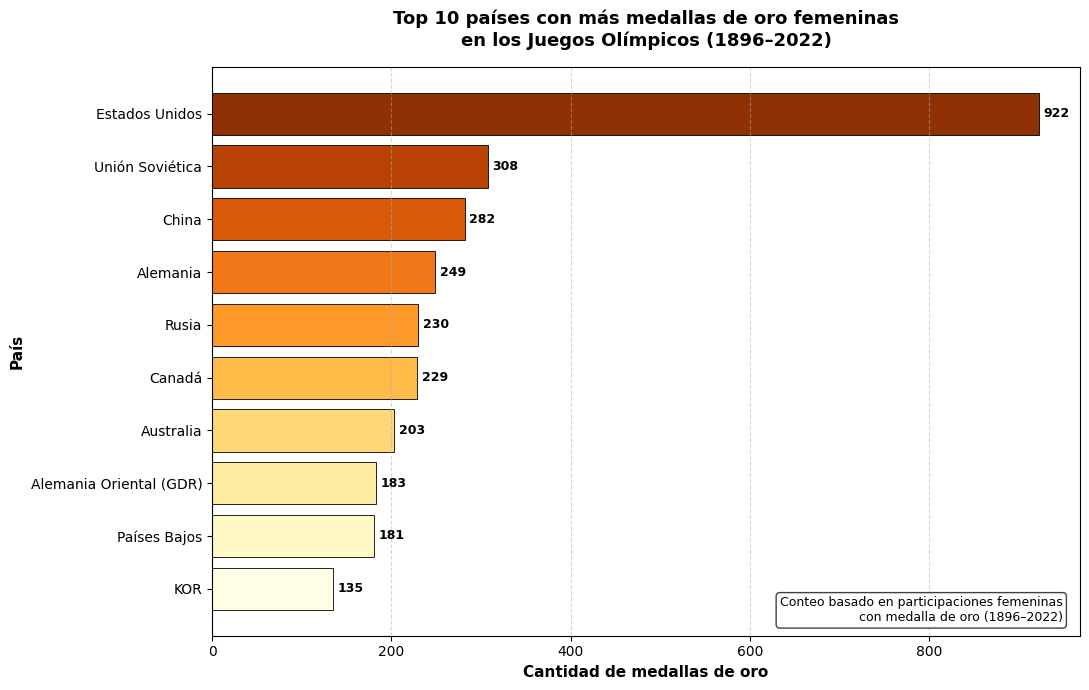

In [68]:
def top10_paises_medallas_oro_femeninas(df):
    d = df[df['sexo'] == 'Mujer'].copy()

    # Filtrar solo medallas de oro
    d = d[d['medalla'].astype(str) == 'Gold']

    # Contar medallas de oro por país y tomar el top 10
    top10 = (d.groupby('pais_codigo').size()
              .sort_values(ascending=False)
              .head(10)
              .reset_index(name='medallas_oro'))

    # Nombres completos de países
    nombres_paises = {
        'USA': 'Estados Unidos',
        'CAN': 'Canadá',
        'GBR': 'Gran Bretaña',
        'GER': 'Alemania',
        'JPN': 'Japón',
        'AUS': 'Australia',
        'CHN': 'China',
        'RUS': 'Rusia',
        'NED': 'Países Bajos',
        'FRA': 'Francia',
        'NOR': 'Noruega',
        'SWE': 'Suecia',
        'ITA': 'Italia',
        'URS': 'Unión Soviética',
        'GDR': 'Alemania Oriental (GDR)',
        'ROU': 'Rumanía'
    }
    top10['pais'] = top10['pais_codigo'].map(lambda x: nombres_paises.get(x, x))

    # Ordenar de menor a mayor para que el mayor quede arriba
    top10 = top10.sort_values('medallas_oro', ascending=True)

    # Colores degradados de amarillo a dorado
    colores = plt.cm.YlOrBr([i / len(top10) for i in range(len(top10))])

    fig, ax = plt.subplots(figsize=(11, 7))

    barras = ax.barh(top10['pais'], top10['medallas_oro'], color=colores, edgecolor='black', linewidth=0.6)

    # Etiqueta con el número al final de cada barra
    for barra, valor in zip(barras, top10['medallas_oro']):
        ax.text(
            barra.get_width() + 5, barra.get_y() + barra.get_height() / 2,
            str(valor), va='center', fontsize=9, fontweight='bold'
        )

    # Información básica dentro del gráfico
    ax.text(
        0.98, 0.02,
        'Conteo basado en participaciones femeninas\ncon medalla de oro (1896–2022)',
        transform=ax.transAxes, fontsize=9, va='bottom', ha='right',
        bbox=dict(facecolor='white', alpha=0.75, boxstyle='round')
    )

    ax.set_title(
        'Top 10 países con más medallas de oro femeninas\nen los Juegos Olímpicos (1896–2022)',
        fontsize=13, fontweight='bold', pad=15
    )

    ax.set_xlabel('Cantidad de medallas de oro', fontsize=11, fontweight='bold')
    ax.set_ylabel('País', fontsize=11, fontweight='bold')
    ax.grid(axis='x', linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()

top10_paises_medallas_oro_femeninas(df)

## **Línea: Evolución del número de disciplinas olímpicas con participación femenina (1896–2022)**

Este gráfico muestra cómo fue aumentando la cantidad de disciplinas deportivas que contaron con participación femenina en cada edición de los Juegos Olímpicos.

Permite visualizar el proceso de apertura del deporte olímpico hacia las mujeres: en qué momentos históricos se incorporaron más disciplinas y cómo ese número creció sostenidamente con el paso de las décadas.

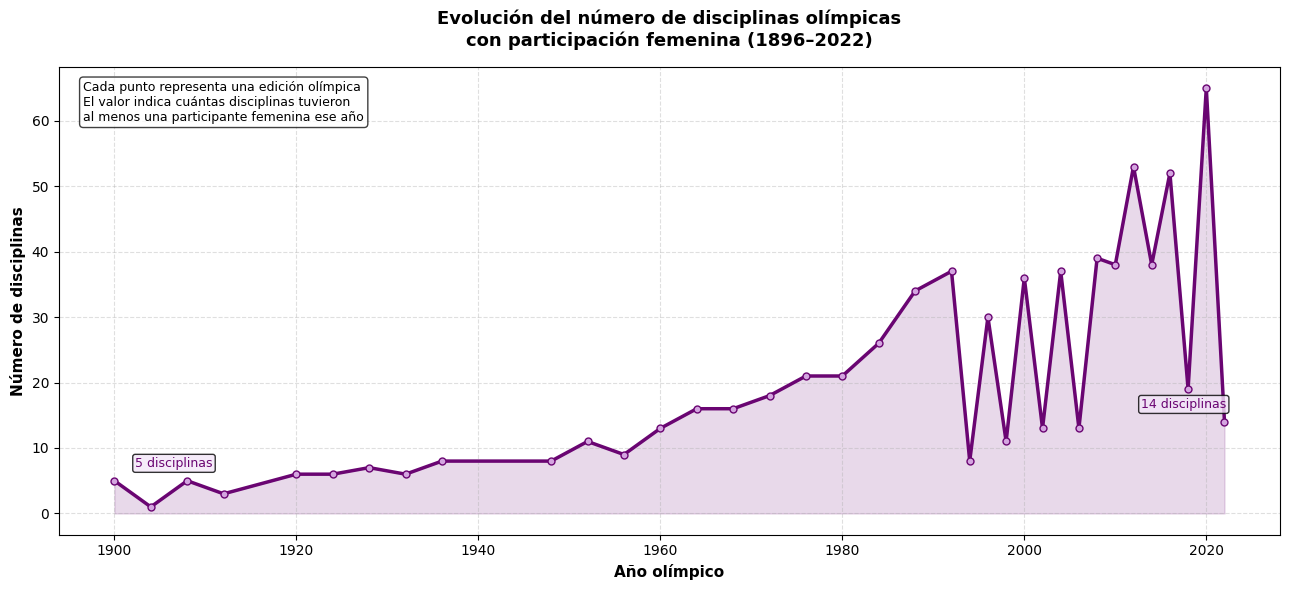

In [69]:
def evolucion_disciplinas_con_mujeres(df):
    d = df[df['sexo'] == 'Mujer'].copy()
    d['año'] = pd.to_numeric(d['año'], errors='coerce')
    d = d.dropna(subset=['año', 'disciplina'])

    # Contar disciplinas únicas con participación femenina por año
    disciplinas_por_anio = (d.groupby('año')['disciplina']
                            .nunique()
                            .reset_index(name='numero_disciplinas')
                            .sort_values('año'))

    fig, ax = plt.subplots(figsize=(13, 6))

    ax.plot(
        disciplinas_por_anio['año'],
        disciplinas_por_anio['numero_disciplinas'],
        color='#6A0572',
        linewidth=2.5,
        marker='o',
        markersize=5,
        markerfacecolor='#D4A5E0',
        markeredgecolor='#6A0572'
    )

    # Sombrear el área bajo la línea
    ax.fill_between(
        disciplinas_por_anio['año'],
        disciplinas_por_anio['numero_disciplinas'],
        alpha=0.15,
        color='#6A0572'
    )

    # Anotar el primer y último valor
    primer = disciplinas_por_anio.iloc[0]
    ultimo = disciplinas_por_anio.iloc[-1]

    ax.annotate(
        f"{int(primer['numero_disciplinas'])} disciplinas",
        xy=(primer['año'], primer['numero_disciplinas']),
        xytext=(15, 10), textcoords='offset points',
        fontsize=9, color='#6A0572',
        bbox=dict(boxstyle='round,pad=0.2', facecolor='#f3e6f8', alpha=0.8)
    )

    ax.annotate(
        f"{int(ultimo['numero_disciplinas'])} disciplinas",
        xy=(ultimo['año'], ultimo['numero_disciplinas']),
        xytext=(-60, 10), textcoords='offset points',
        fontsize=9, color='#6A0572',
        bbox=dict(boxstyle='round,pad=0.2', facecolor='#f3e6f8', alpha=0.8)
    )


    #Para aque sea vean todos los puntos (anotar todos los puntos)
    #for _, row in disciplinas_por_año.iterrows():
        #ax.annotate(
            #str(int(row['num_disciplinas'])),
            #xy=(row['year'], row['num_disciplinas']),
            #xytext=(0, 8), textcoords='offset points',
            #fontsize=7, ha='center', color='#6A0572'
        #)


    # Información básica dentro del gráfico
    ax.text(
        0.02, 0.97,
        'Cada punto representa una edición olímpica\n'
        'El valor indica cuántas disciplinas tuvieron\n'
        'al menos una participante femenina ese año',
        transform=ax.transAxes, fontsize=9, va='top',
        bbox=dict(facecolor='white', alpha=0.75, boxstyle='round')
    )

    ax.set_title(
        'Evolución del número de disciplinas olímpicas\ncon participación femenina (1896–2022)',
        fontsize=13, fontweight='bold', pad=15
    )
    ax.set_xlabel('Año olímpico', fontsize=11, fontweight='bold')
    ax.set_ylabel('Número de disciplinas', fontsize=11, fontweight='bold')
    ax.grid(True, linestyle='--', alpha=0.4)
    plt.tight_layout()
    plt.show()

evolucion_disciplinas_con_mujeres(df)